# Summary 

### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/

Read in process_uber_summary.parquet (Can be downloaded from https://gdo168.llnl.gov/data/ACME4/gold/process_uber_summary.parquet) 


In [1]:
%%time
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from collections import Counter
import warnings

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


CPU times: user 6.68 s, sys: 169 ms, total: 6.85 s
Wall time: 1.72 s


# Exploring the files


In [2]:
## the table can be found here: https://gdo168.llnl.gov/data/ACME4/stdview-20240819-20240923/
files = pd.read_parquet("Data/process_file.parquet")


In [5]:
files.columns

Index(['agent_id', 'Hostname', 'pid_hash', 'process_name', 'file_id',
       'file_hash', 'filename', 'activity_type', 'bytes_requested',
       'event_count', 'num_raw_rows', 'first_seen', 'last_seen', 'min_event',
       'max_event'],
      dtype='object')

In [6]:
files[['pid_hash', 'process_name', 'filename']]

,pid_hash,process_name,filename
0,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\windows\system32\samcli.dll
1,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\windows\temp
2,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\programdata\wintap\logs\wintap.log
3,B696A80670588C5193175908523F8068,ntoskrnl.exe,c:\$logfile
4,FC2EC18B2ECC85580CFD8287B0A85E5A,mergehelper.exe,c:\program files\dotnet\shared\microsoft.netco...
...,...,...,...
9343194,7BAAE96741807787EFD2D6522B8C6B04,unknown,c:\programdata\amazon\ssm\instancedata\i-022a6...
9343195,6FB634509A57999E72BCAFA74A8FFF29,ssm-agent-worker.exe,c:\programdata\amazon\ssm\instancedata\i-0b786...
9343196,D100E700543C6C09201C9F7C5302F6B8,wmic.exe,c:\windows\system32\wbem\textvaluelist.xsl
9343197,6FB634509A57999E72BCAFA74A8FFF29,ssm-agent-worker.exe,c:\programdata\amazon\ssm\instancedata\i-0b786...


In [30]:
F = files.filename.tolist()
len(F)

9343199

In [32]:
F = list(set(F))

In [33]:
S = [f.split('\\') for f in F]

In [34]:
Counter([s[0] for s in S])


Counter({'c:': 2652025, '': 1552, 'd:': 1, 'e:': 1, 'f:': 1})

In [35]:
S = [s[1:] for s in S]
Counter([len(s) for s in S])


Counter({9: 802886,
         8: 799663,
         5: 252146,
         11: 222313,
         6: 173121,
         10: 117264,
         7: 97925,
         13: 52192,
         12: 42335,
         14: 32314,
         4: 28058,
         3: 11312,
         15: 8834,
         16: 7911,
         17: 1965,
         18: 1401,
         2: 898,
         20: 777,
         19: 168,
         1: 71,
         21: 17,
         23: 5,
         22: 4})

In [51]:
import igraph as ig
## our matching algorithm
import igraph_io as igio
import fast_match as fm  ## fast version

In [220]:
%%time
TreeData = []
path_len = 7
users = []
for s in S:
    if len(s) == path_len:
        sg = ig.Graph.TupleList([(i,i+1) for i in range(len(s)-1)], directed=True)
        sg.vs['dir'] = s
        if 'baduser3' in s:
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
            users.append('baduser3')
        elif 'user1' in s:
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
            users.append('user1')
        elif 'user3' in s:
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
            users.append('user3')


CPU times: user 1.71 s, sys: 28.1 ms, total: 1.73 s
Wall time: 1.72 s


In [221]:
%%time
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]
len(enc)

CPU times: user 114 ms, sys: 825 μs, total: 115 ms
Wall time: 115 ms


7959

In [ ]:
templates = np.where(np.array(users)=='baduser3')[0].tolist()

for base in templates:
    ctr_last = 0
    ctr = 0
    #base = np.random.choice(len(enc))
    l = len(enc[base].label_ids)
    for i in range(len(enc)):
        if (i!=base) and (len(enc[i].label_ids)==l) and ('baduser3' not in enc[i].tree.label):
            _, score = fast.predict_encoded(enc[base], enc[i])
            x.append(score)
            if score==(l-1): 
                if _[l-2] != (l-2,l-2):
                    ctr += 1
                    if ctr==1:
                        print(enc[base].tree.label)
                    print(enc[i].tree.label)
                else:
                    ctr_last+=1
    if ctr>0:
        print(ctr,'mismatch inside path',ctr_last,'mismatch on last item\n')


['users', 'baduser3', 'appdata', 'roaming', 'microsoft', 'windows', 'printer shortcuts']
['users', 'user3', 'appdata', 'roaming', 'microsoft', 'windows', 'printer shortcuts']
['users', 'user1', 'appdata', 'roaming', 'microsoft', 'windows', 'printer shortcuts']
2 mismatch inside path 0 mismatch on last item

['users', 'baduser3', 'appdata', 'local', 'packages', 'e2a4f912-2574-4a75-9bb0-0d023378592b_cw5n1h2txyewy', 'systemappdata']
['users', 'user1', 'appdata', 'local', 'packages', 'e2a4f912-2574-4a75-9bb0-0d023378592b_cw5n1h2txyewy', 'systemappdata']
1 mismatch inside path 0 mismatch on last item

['users', 'baduser3', 'appdata', 'roaming', 'microsoft', 'spelling', '']
['users', 'user1', 'appdata', 'roaming', 'microsoft', 'spelling', '']
1 mismatch inside path 0 mismatch on last item

['users', 'baduser3', 'appdata', 'local', 'packages', 'microsoft.windows.pinningconfirmationdialog_cw5n1h2txyewy', 'localcache']
['users', 'user1', 'appdata', 'local', 'packages', 'microsoft.windows.pinnin

In [142]:
enc[base].tree.label

['programdata',
 'anaconda3',
 'pkgs',
 'spyder-5.4.3-py311haa95532_1',
 'lib',
 'site-packages',
 'spyder',
 'api',
 'plugin_registration',
 'mixins.py']

In [143]:
len(enc)

117264

In [17]:
## some sigma ids are very common!
Counter(sigma.analytic_id).most_common(5)


[('4fc0deee-0057-4998-ab31-d24e46e0aba4', 12303554),
 ('f208d6d8-d83a-4c2c-960d-877c37da84e5', 5501388),
 ('71158e3f-df67-472b-930e-7d287acaa3e1', 5042822),
 ('9d7ca793-f6bd-471c-8d0f-11e68b2f0d2f', 1925188),
 ('e4a6b256-3e47-40fc-89d2-7a477edd6915', 594966)]

### compute scores 

* sum of counts
* sum of inverse frequencies


In [18]:
%%time
_sigma_dict = sigma["analytic_id"].value_counts().to_dict()
sigma['inv_freqs'] = [1/_sigma_dict[x] for x in sigma.analytic_id]
sigma['counts'] = 1
_sigma = sigma.groupby(by='entity', as_index=False)[['inv_freqs','counts']].sum()

## add count-based score
_sigma_dict = dict(zip(_sigma['entity'], _sigma['counts']))
process['score_counts'] = [_sigma_dict.get(x,0) for x in process['pid_hash']]

## add inverse frequency based score
_sigma_dict = dict(zip(_sigma['entity'], _sigma['inv_freqs']))
process['score_inv_freqs'] = [_sigma_dict.get(x,0) for x in process['pid_hash']]


CPU times: user 20.1 s, sys: 947 ms, total: 21.1 s
Wall time: 21.1 s


### using the counts score as sole predictor

this is clearly better than random, with a number of "early hits" on the ROC curve


AUC:, 0.8019411398896752


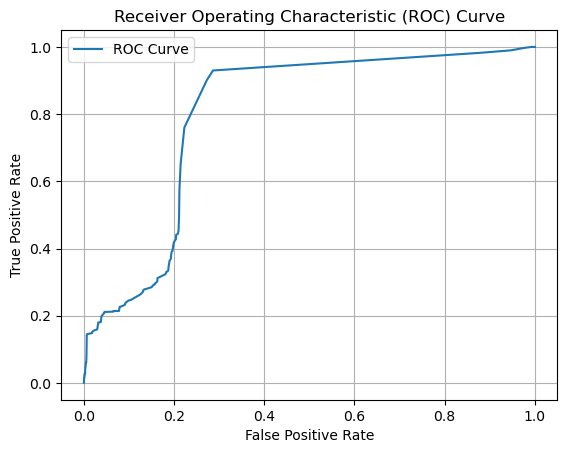

In [19]:
fpr, tpr, thresholds = roc_curve(process.is_bad, process.score_counts)
print('AUC:,',auc(fpr, tpr))
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### using the inverse frequencies score as sole predictor

this is even better than random, with a lot of "early hits" on the ROC curve and higher AUC

next we add this feature to our random forest model


AUC:, 0.8776452542530271


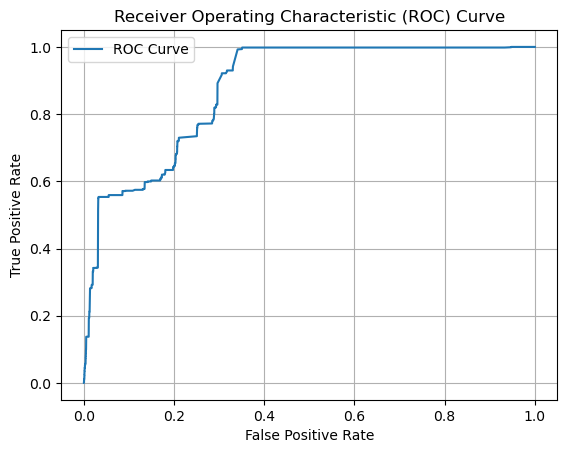

In [20]:
fpr, tpr, thresholds = roc_curve(process.is_bad, process.score_inv_freqs)
print('AUC:,',auc(fpr, tpr))
plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### Adding the inverse frequency sigma-based feature to our simple forest model

ROC curve is almost the same, but we see the inverse frequency score as the second most important feature.


In [21]:
num_col.append('score_inv_freqs')


In [22]:
## random forest
X = process[num_col]

## pick one
#y = process['is_bad']
y = process['red_team']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


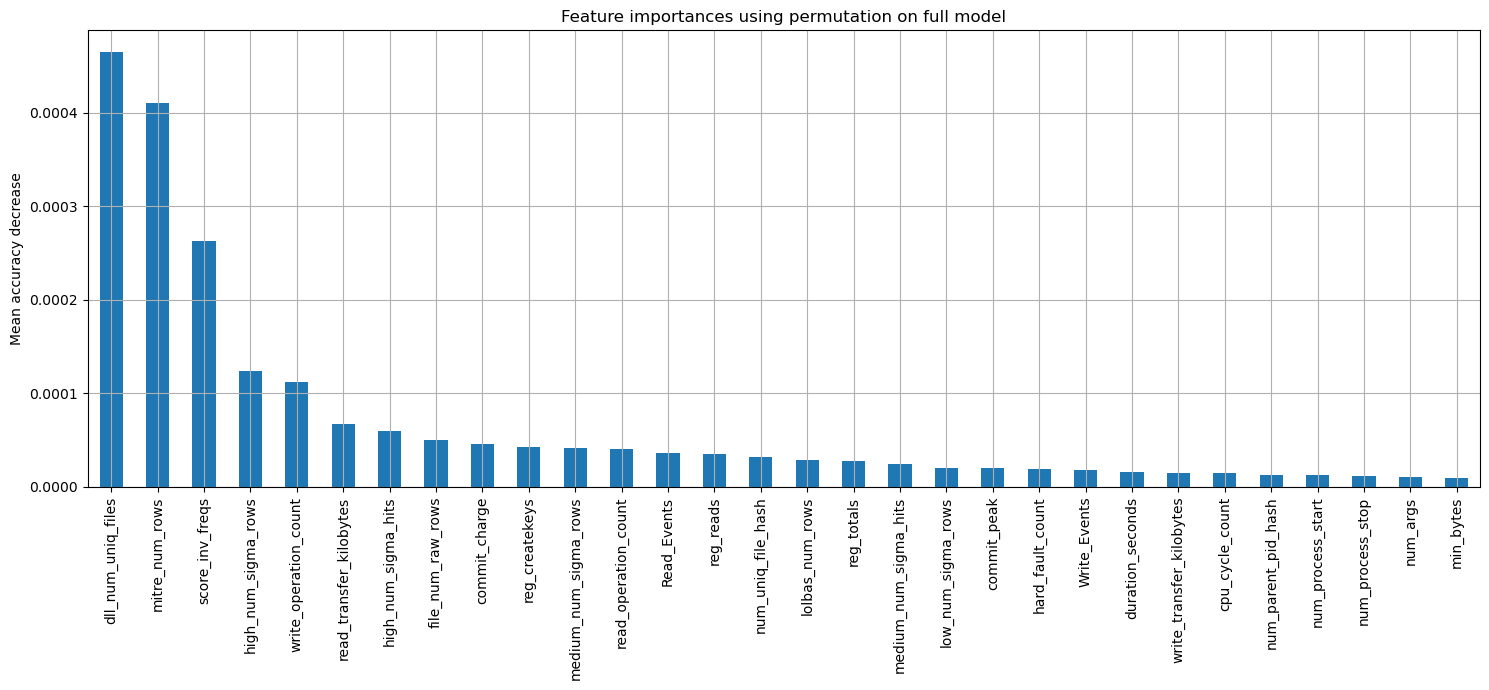

In [23]:
## variable importance
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=1
)

## plot top ones
_top = 30
forest_importances = pd.Series(result.importances_mean, index=num_col).sort_values(ascending=False)[:_top]
fig, ax = plt.subplots(figsize=(15,7))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.grid()
plt.show()


AUC:, 0.9943226038656694


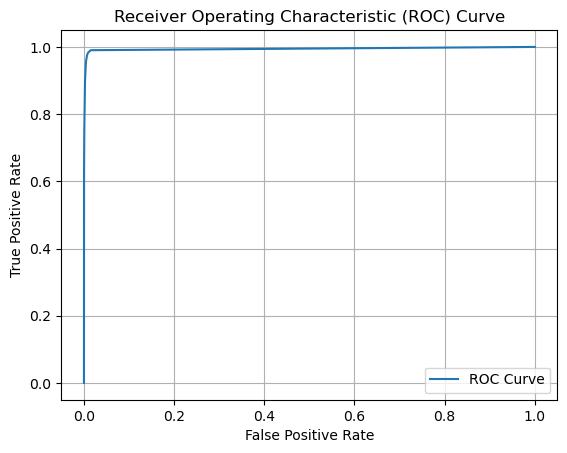

In [24]:
## ROC and AUC
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### precision, recall and F1 vs threshold


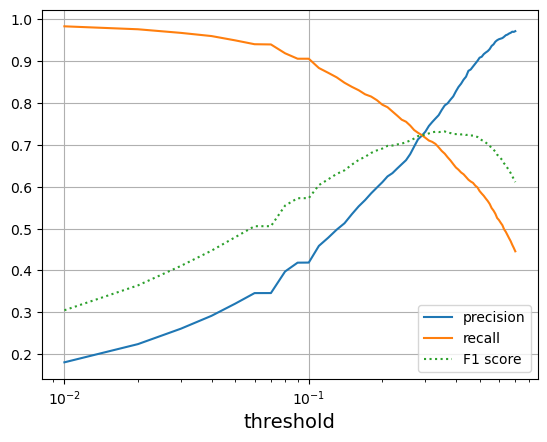

In [25]:
L = []
for th in np.arange(.01,.71,.01):
    y_pred = y_pred_proba > th
    cm = confusion_matrix(y_test,y_pred)
    fp = cm[0,1]
    tp = cm[1,1]
    fn = cm[1,0]
    F = 2*tp/(2*tp+fp+fn)
    L.append([th, fp, tp, fn, tp/(tp+fp), tp/(tp+fn), F])

_df = pd.DataFrame(L, columns=['weight','fp','tp','fn','precision','recall','F1'])
plt.semilogx(_df.weight, _df.precision, label='precision')
plt.semilogx(_df.weight, _df.recall, label='recall')
plt.semilogx(_df.weight, _df.F1, label='F1 score', ls=':')
plt.grid()
plt.xlabel('threshold', fontsize=14)
plt.legend();


# (4) A simple CART classification model

In view of the above results, we try a simple, very interpretable classification tree using the same approach.

We can actually visualize the top splits in the tree.

Results from the confusion matrix are only slightly worse than with a random forest.

**NB:** with decision trees, missing values are lumped together and assigned to the split that yields the best score, as with RFs


In [26]:
## Fit the model
from sklearn.tree import DecisionTreeClassifier
X = process[num_col]

## pick one
y = process['is_bad']
y = process['red_team']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


### handling class imbalance


In [27]:
print('imbalance factor:',1/(sum(y_train)/len(y_train)))
L = []
for rw in [1,2,3,4,5,6,7,8,9,10,15,20,30,40,50,100,1000]:
    cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:rw}) ## re-weight due to class imbalance
    cart.fit(X_train, y_train)
    y_pred = cart.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)
    fp = cm[0,1]
    tp = cm[1,1]
    fn = cm[1,0]
    F = 2*tp/(2*tp+fp+fn)
    L.append([rw, fp, tp, fn, tp/(tp+fp), tp/(tp+fn), F])
    

imbalance factor: 487.60891089108907


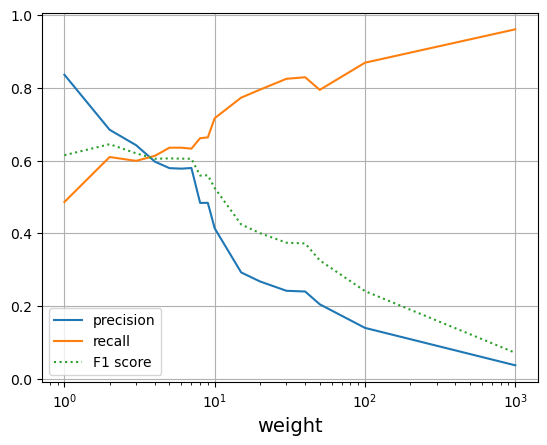

In [28]:
_df = pd.DataFrame(L, columns=['weight','fp','tp','fn','precision','recall','F1'])
plt.semilogx(_df.weight, _df.precision, label='precision')
plt.semilogx(_df.weight, _df.recall, label='recall')
plt.semilogx(_df.weight, _df.F1, label='F1 score', ls=':')
plt.grid()
plt.xlabel('weight', fontsize=14)
plt.legend();


In [29]:
## optimal weight w.r.t. F1 score
w_f1 = int(_df.weight[_df.F1 == max(_df.F1)].iloc[0])


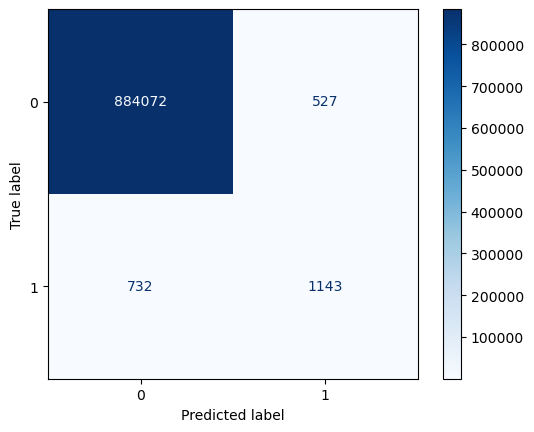

In [30]:
# Create a DecisionTreeClassifier instance
cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:w_f1}) ## re-weight with optimal 

# Train the classifier
cart.fit(X_train, y_train)

# Make predictions
y_pred = cart.predict(X_test)

## Confusion matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


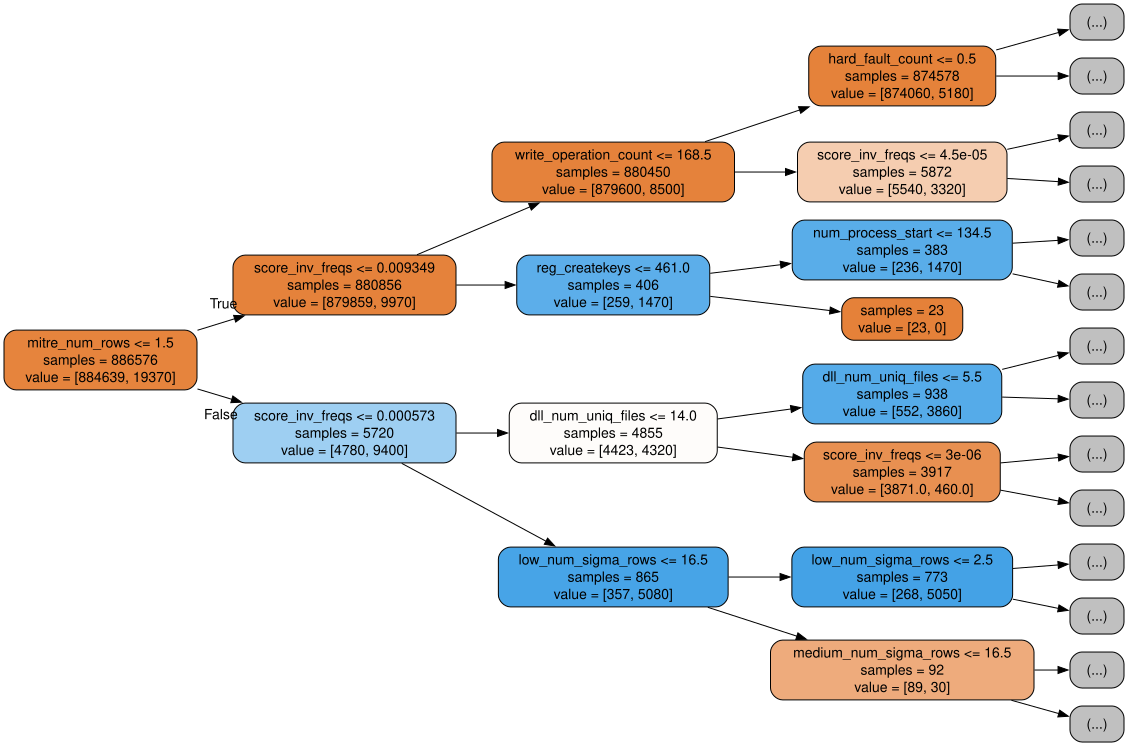

In [43]:
## nb: counts are "off" due to re-weighting
dot_data = export_graphviz(cart,
                           feature_names=X_train.columns,  
                           filled=True,  
                           max_depth=3, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)


# (5) Reverse the labels - try dropping "likely ok stuff"

This is really the same model, but we look at the confusion matrix for the angle of dropping "non-bad" processes.

Adjusting the threshold, we can remove most "non-bad" while retaining a large proportion of the baduser processes.


In [31]:
## simple random forest
X = process[num_col]

## pick one
#y = [not x for x in process['is_bad']] ## reverse the labels
y = [not x for x in process['red_team']] ## reverse the labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AUC:, 0.9970038853763117


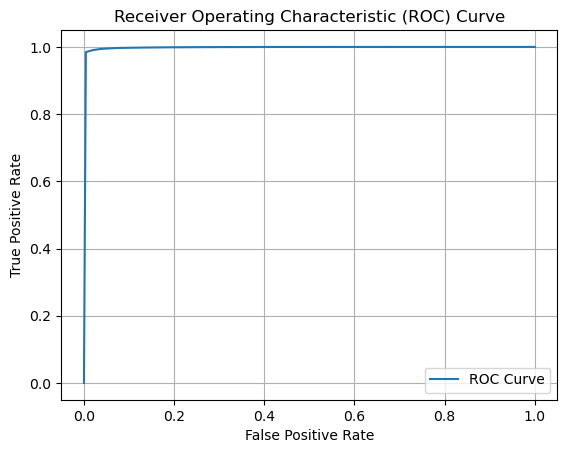

In [32]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


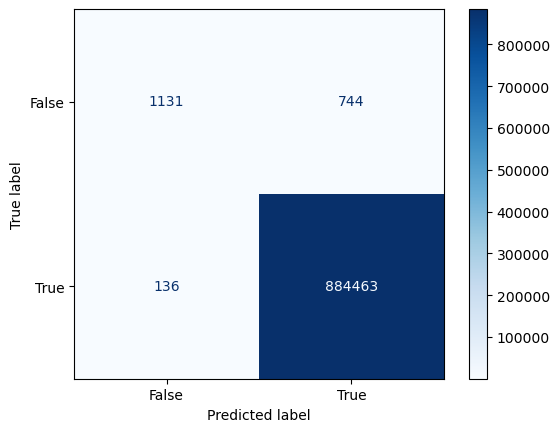

In [33]:
## mid range threshold
y_pred = y_pred_proba > .50
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


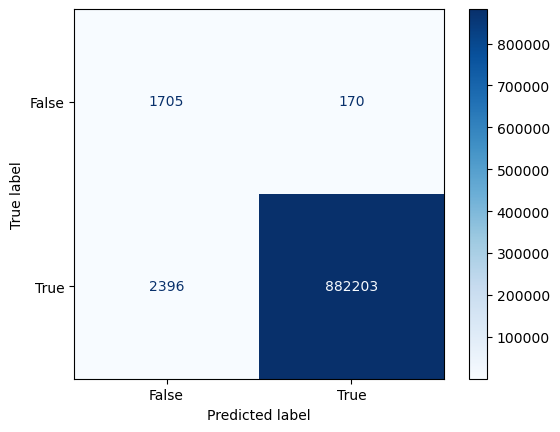

In [34]:
## high threshold
y_pred = y_pred_proba > .90
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


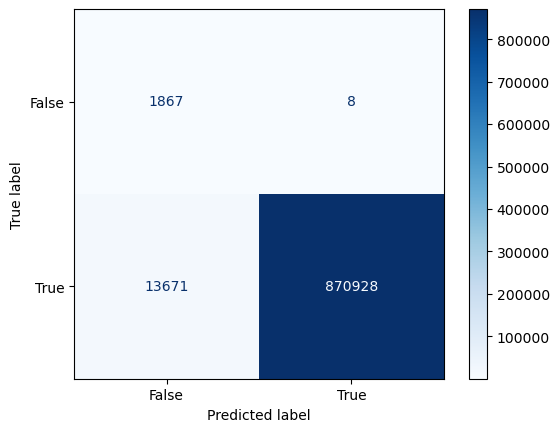

In [35]:
## very high threshold
y_pred = y_pred_proba > .99
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


# (6) A different train-test split

For the positive labels, consider trees involving the same baduser(s) for training, and a disjoint set of baduser(s) for testing.
There are only 3 'badusers', one of which has only 40 instances. Separating the other two between test/train yields similar results.
The ROC curve show that we can recover around 60% of the test set, but looking deeper, all probability scores are very low, with most cases getting 0 probability.
Thus there is some signal, but nowhere near the previous experiments. So in short:
* many badusers processes are easy to differentiate from the other processes
* processes from different badusers are also quite different, but have some simlarity that still allows to differentiate from "other" process in a weak fashion


In [36]:
## split negative cases randomly
X = process[process.baduser==0][num_col]

## pick one
#y = process[process.baduser==0]['is_bad']
y = process[process.baduser==0]['red_team']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## split positive cases by 'baduser'
bad_train = [9, 25]
bad_test = [3]

X_train = pd.concat([X_train,process[process.baduser.isin(bad_train)][num_col]], ignore_index=True)
X_test = pd.concat([X_test,process[process.baduser.isin(bad_test)][num_col]], ignore_index=True)
y_train = pd.concat([y_train, process[process.baduser.isin(bad_train)]['red_team']], ignore_index=True)
y_test = pd.concat([y_test, process[process.baduser.isin(bad_test)]['red_team']], ignore_index=True)


In [37]:
## simple random forest
rf = RandomForestClassifier(n_jobs=25, class_weight={0:1, 1:10})
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AUC:, 0.9390737469796275


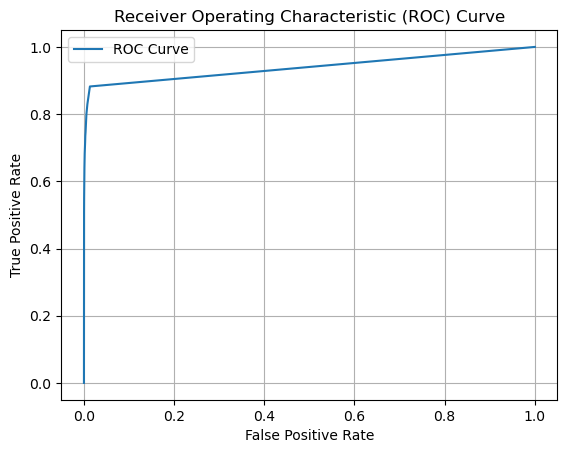

In [38]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


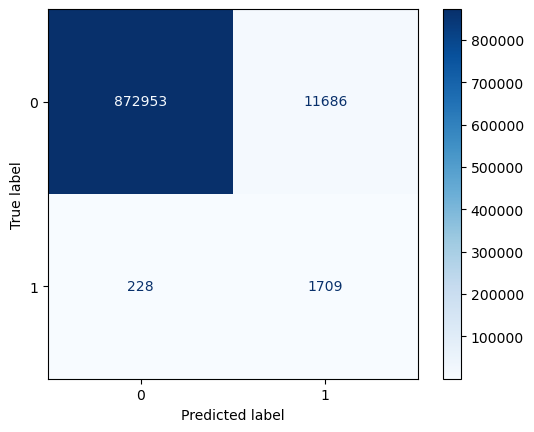

In [39]:
y_pred = y_pred_proba > 0
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


AUC:, 0.8888974038541363


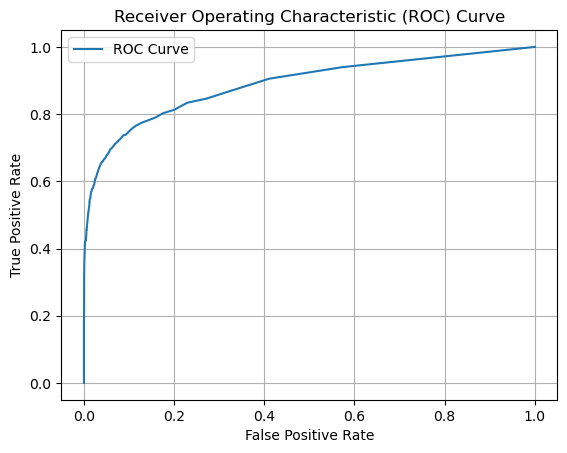

In [40]:
## ROC w.r.t. the positive scoring cases only ...
y_pred_proba = rf.predict_proba(X_test)[:,1]
b = y_pred_proba>0
fpr, tpr, thresholds = roc_curve(y_test[b], y_pred_proba[b])
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


### look at paths in CART 

Quite different trees when looking at training or test datasets ... the badusers are not so similar after all ... 


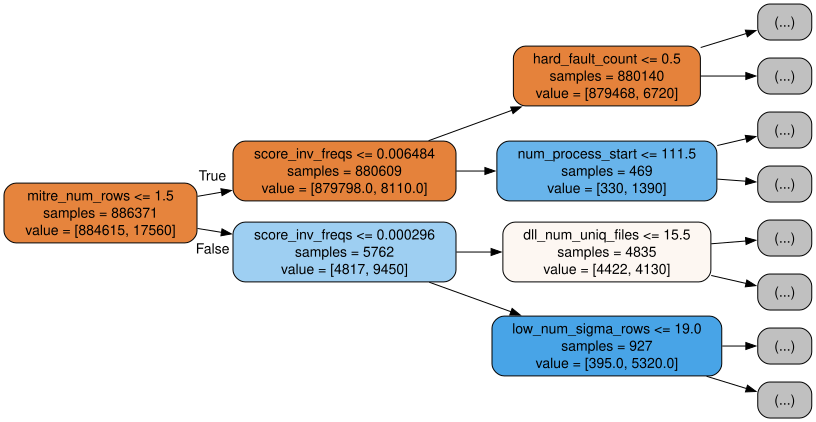

In [41]:
# Create a DecisionTreeClassifier instance - training data (baduser9 mainly)
cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:10})
cart.fit(X_train, y_train)

dot_data = export_graphviz(cart,
                           feature_names=X.columns,  
                           filled=True,  
                           max_depth=2, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)


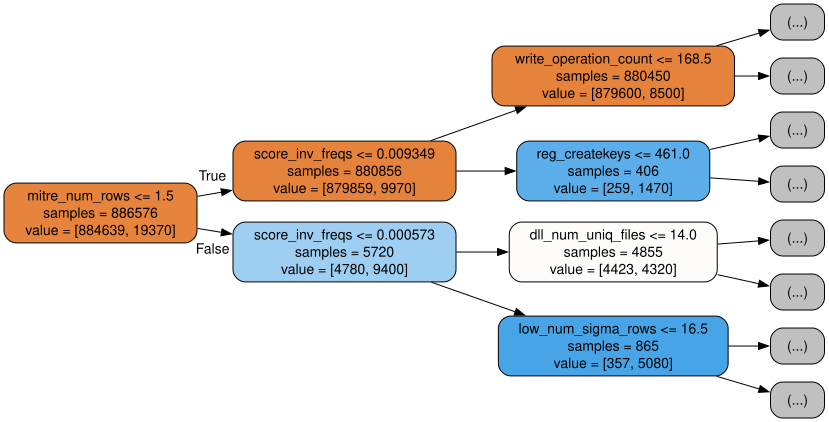

In [42]:
# Create a DecisionTreeClassifier instance - test data (baduser3)
## this is closer to the overall model we trained earlier, which was better at recovering baduser3 than baduser9

cart = DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:10})
cart.fit(X_test, y_test)

dot_data = export_graphviz(cart,
                           feature_names=X.columns,  
                           filled=True,  
                           max_depth=2, 
                           precision=6,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)
